In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# getting the query file
# load csv from github
import pandas as pd

queries_df = pd.read_csv("/rhome/sawale/indus_traning/sentense_transformers/data/code_readme_dataset/code_validation_data_v2.csv")
corpus_df = pd.read_csv("/rhome/sawale/indus_traning/sentense_transformers/data/code_readme_dataset/repositories_with_embeddings_v6.csv")

template = """
`Description`: {},

`Reformulated Text`: {},

`Key Topics`: {},

`Relevant Content`: {}
"""

# ensure no NaNs and convert to str
corpus_df = corpus_df.fillna("")
corpus_df['_text'] = corpus_df.apply(
    lambda row: template.format(
        row['description'],
        row['reformulated_text'],
        row['key_topics'],
        row['relevant_content']
    ),
    axis=1
)

print("before dropping duplicates:", queries_df.shape, corpus_df.shape)
# dropping duplicates for queries_df based on question, url, division (all columns)
queries_df = queries_df.drop_duplicates(subset=['question', 'url', 'division'])
corpus_df = corpus_df.drop_duplicates(subset=['_text'])
print("after dropping duplicates:", queries_df.shape, corpus_df.shape)

before dropping duplicates: (215, 3) (5445, 14)
after dropping duplicates: (215, 3) (5397, 14)


In [3]:
queries_df.head()

,question,url,division
0,How do I create PDS labels?,"['https://github.com/NASA-AMMOS/labelocity', '...",Planetary
1,"How do I create a simulated mission, from star...",['https://github.com/NASA-AMMOS/aerie-mission-...,Planetary
2,Is my work compliant and ready to be uploaded ...,['https://github.com/NASA-PDS/data-upload-mana...,Planetary
3,Provide Jupyter notebook examples illustrating...,['https://github.com/Caltech-IPAC/MontageMosai...,Astro
4,Provide Python examples for analysis of Fermi ...,['https://github.com/fermi-lat/AnalysisThreads...,Astro


In [4]:
# queries_df["url"] is str but its a list so using eval to convert it to list
queries_df["url"] = queries_df["url"].apply(eval)


In [5]:
queries_df["division"].unique()

array(['Planetary', 'Astro', 'Earth'], dtype=object)

In [6]:
corpus_df.head()

,URL,text,reformulated_text,key_topics,area,reasoning,source,readme_url,description,name,relevant_content,relevant_reasoning,embeddings,_text
0,https://github.com/Caltech-IPAC/Kepler-Discove...,Kepler-Discoveries ====== Software repository ...,Kepler-Discoveries is a software repository de...,Kepler Mission | NExScI | NASA Exoplanet Archi...,Astrophysics Division,The README content mentions the Kepler Mission...,Org,https://github.com/Caltech-IPAC/Kepler-Discove...,Utility scripts using the NASA Exoplanet Archi...,Kepler-Discoveries,,,"-0.0074941935,0.024302335,0.0007752162,-0.0270...",\n`Description`: Utility scripts using the NAS...
1,https://github.com/Caltech-IPAC/Montage,"Montage: Astronomical Image Mosaics, Examinati...",Montage is an open-source toolkit designed for...,Montage | astronomical image mosaics | FITS im...,Astrophysics Division,"The README describes Montage, a toolkit for as...",Org,https://github.com/Caltech-IPAC/Montage/blob/m...,Image Mosaics for Astronomers,Montage,,,"0.005070961,-0.0024839384,-0.028777495,-0.0232...",\n`Description`: Image Mosaics for Astronomers...
2,https://github.com/Caltech-IPAC/MontageMosaics,Jupyter Notebooks for Building Astronomical Mo...,Montage is an open-source toolkit licensed und...,Montage | astronomical mosaics | image process...,Astrophysics Division,"The README describes Montage, a toolkit for cr...",Org,https://github.com/Caltech-IPAC/MontageMosaics...,,MontageMosaics,,,"0.005882572,0.01452603,-0.009796207,-0.026566,...","\n`Description`: ,\n\n`Reformulated Text`: Mo..."
3,https://github.com/Caltech-IPAC/MontageNotebooks,Montage Notebooks: Jupyter notebooks illustrat...,Montage Notebooks provide Jupyter notebooks th...,Montage Notebooks | Jupyter notebooks | astron...,Astrophysics Division,"The README describes Montage, a toolkit for as...",Org,https://github.com/Caltech-IPAC/MontageNoteboo...,Jupyter notebooks illustrating the use of the ...,MontageNotebooks,,,"0.02123165,-0.0016249721,0.0004058171,-0.02378...",\n`Description`: Jupyter notebooks illustratin...
4,https://github.com/Caltech-IPAC/TESSCoadds,"# <font color=""#880000""> Image Cutouts of Co-A...",Image Cutouts of Co-Added TESS Full Frame Imag...,TESS | Transiting Exoplanet Sky Survey | CCD c...,Astrophysics Division,The README describes the Transiting Exoplanet ...,Org,https://github.com/Caltech-IPAC/TESSCoadds/blo...,,TESSCoadds,,,"-0.012586548,0.00053917244,-0.005944926,-0.013...","\n`Description`: ,\n\n`Reformulated Text`: Im..."


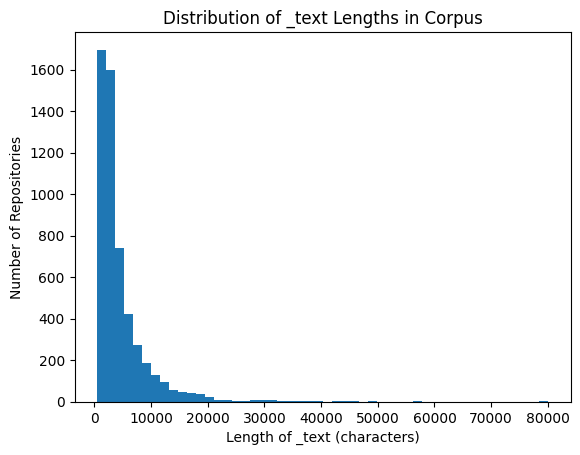

count     5397.000000
mean      4482.143969
std       4692.500611
min        475.000000
25%       1811.000000
50%       2911.000000
75%       5279.000000
max      80025.000000
Name: _text_length, dtype: float64


In [7]:
# let get the distribution of _text lengths (baed on character)
corpus_df["_text_length"] = corpus_df["_text"].apply(len)
import matplotlib.pyplot as plt
plt.hist(corpus_df["_text_length"], bins=50)
plt.xlabel("Length of _text (characters)")
plt.ylabel("Number of Repositories")
plt.title("Distribution of _text Lengths in Corpus")
plt.show()

# also print the five point summary of _text lengths
print(corpus_df["_text_length"].describe())


Token indices sequence length is longer than the specified maximum sequence length for this model (1177 > 1024). Running this sequence through the model will result in indexing errors


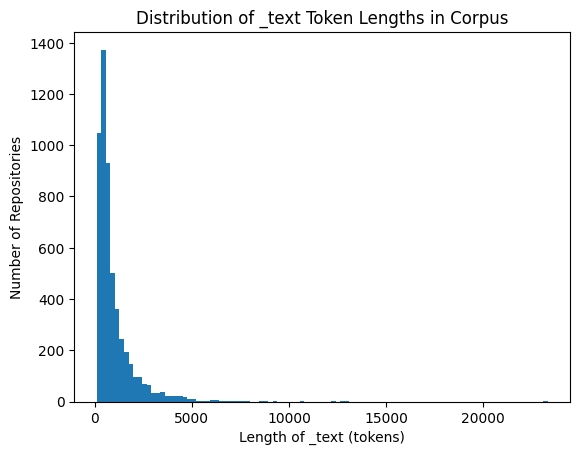

count     5397.000000
mean       982.399481
std       1076.058303
min        110.000000
25%        389.000000
50%        629.000000
75%       1149.000000
max      23325.000000
Name: _text_token_length, dtype: float64
99th percentile: 5030.0


In [8]:
# now instead of char length based, let count tokenizer based length
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("nasa-impact/indus-sde-st-v0.2")

corpus_df["_text_token_length"] = corpus_df["_text"].apply(lambda x: len(tokenizer.tokenize(x)))
plt.hist(corpus_df["_text_token_length"], bins=100)
plt.xlabel("Length of _text (tokens)")
plt.ylabel("Number of Repositories")
plt.title("Distribution of _text Token Lengths in Corpus")
plt.show()

# also print the five point summary of _text token lengths
print(corpus_df["_text_token_length"].describe())
# also add 99 percentile
print("99th percentile:", corpus_df["_text_token_length"].quantile(0.99))


In [12]:
import pandas as pd
import json
import os

# ==========================================
# 0. HELPER FUNCTION
# ==========================================
def normalize_url(url: str) -> str:
    """Normalizes a given URL to its canonical form."""
    if not isinstance(url, str):
        return str(url)
    if '://' not in url:
        url = 'http://' + url
    try:
        from urllib.parse import urlparse, urlunparse, parse_qs, urlencode
        parsed_url = urlparse(url)
        scheme = parsed_url.scheme.lower()
        hostname = parsed_url.hostname.lower() if parsed_url.hostname else ''
        if scheme in ('http', 'https'):
            scheme = 'https'
        if hostname.startswith('www.'):
            hostname = hostname[4:]
        port = parsed_url.port
        original_scheme = parsed_url.scheme.lower()
        if (original_scheme == 'http' and port == 80) or \
           (original_scheme == 'https' and port == 443):
            port = None
        netloc = hostname
        if port:
            netloc += f":{port}"
        fragment = ''
        query_params = parse_qs(parsed_url.query)
        sorted_query = sorted(query_params.items())
        query_string = urlencode(sorted_query, doseq=True)
        path = parsed_url.path
        if len(path) > 1 and path.endswith('/'):
            path = path.rstrip('/')
        
        normalized_components = (scheme, netloc, path, parsed_url.params, query_string, fragment)
        return urlunparse(normalized_components)
    except Exception:
        return url  # Return original URL if parsing fails
    
# ==========================================
# 1. SETUP & DUMMY DATA (Replace with your actual data loading)
# ==========================================

# Example output directory
output_dir = "/rhome/sawale/indus_traning/sentense_transformers/data/code_readme_dataset/benchmark_jsonl"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/qrels", exist_ok=True)

# ---------------------------------------------------------
# 2. PREPARE CORPUS (Documents)
# ---------------------------------------------------------
print("Processing Corpus...")

# Create unique Document IDs
corpus_df['doc_id'] = [str(i) for i in range(len(corpus_df))]

# --- NORMALIZATION STEP ---
# Create a normalized column for reliable matching
corpus_df['url_norm'] = corpus_df['URL'].apply(normalize_url)

# Create a mapping dictionary: Normalized URL -> doc_id
# We use the normalized version for the key, but keep the ID
url_to_docid = dict(zip(corpus_df['url_norm'], corpus_df['doc_id']))

# Write corpus.jsonl
corpus_path = f"{output_dir}/corpus.jsonl"
with open(corpus_path, 'w', encoding='utf-8') as f:
    for _, row in corpus_df.iterrows():
        doc_obj = {
            "_id": row['doc_id'],
            "text": row['_text'],
            "title": row['name'],
            "url": row['URL'] # We save the ORIGINAL URL for display/reference
        }
        f.write(json.dumps(doc_obj, ensure_ascii=False) + '\n')

print(f"Created corpus.jsonl with {len(corpus_df)} documents")

# ---------------------------------------------------------
# 3. PREPARE QUERIES
# ---------------------------------------------------------
print("Processing Queries...")

# Create unique Query IDs
queries_df['query_id'] = [str(i) for i in range(len(queries_df))]

# Write queries.jsonl
queries_path = f"{output_dir}/queries.jsonl"
with open(queries_path, 'w', encoding='utf-8') as f:
    for _, row in queries_df.iterrows():
        query_obj = {
            "_id": row['query_id'],
            "text": row['question'],
            "metadata": {"division": row['division']}
        }
        f.write(json.dumps(query_obj, ensure_ascii=False) + '\n')

print(f"Created queries.jsonl with {len(queries_df)} queries")

# ---------------------------------------------------------
# 4. GENERATE QRELS (Split by Division)
# ---------------------------------------------------------
print("Processing Qrels...")

# Step A: Explode the URL list in queries_df
# Use dropna() first to ensure we don't explode None/NaN lists
queries_exploded = queries_df.dropna(subset=['url']).explode('url')

# --- NORMALIZATION STEP ---
# Apply the same normalization to the exploded query URLs
queries_exploded['url_norm'] = queries_exploded['url'].apply(normalize_url)

# Step B: Map the Normalized URL to the doc_id
queries_exploded['doc_id'] = queries_exploded['url_norm'].map(url_to_docid)

# Step C: Drop rows where no match was found
initial_len = len(queries_exploded)
qrels_df = queries_exploded.dropna(subset=['doc_id'])

dropped_count = initial_len - len(qrels_df)
if dropped_count > 0:
    print(f"Warning: Dropped {dropped_count} qrel pairs because the URL (after normalization) was not found in corpus_df.")
    print("Dropped Urls:")
    print(queries_exploded.loc[queries_exploded['doc_id'].isna(), 'url_norm'].unique())

# Step D: Group by 'division' and write separate files
divisions = qrels_df['division'].unique()

for division in divisions:
    # Filter data for this division
    div_data = qrels_df[qrels_df['division'] == division]
    
    # Prepare the standard format: query-id, corpus-id, score
    output_qrels = pd.DataFrame({
        'query-id': div_data['query_id'],
        'corpus-id': div_data['doc_id'],
        'score': 1
    })
    
    # Define filename (sanitize division name)
    safe_div_name = str(division).replace(" ", "_").lower()
    file_path = f"{output_dir}/qrels/{safe_div_name}.tsv"
    
    # Save to TSV
    output_qrels.to_csv(file_path, sep='\t', index=False)
    print(f"Created qrels/{safe_div_name}.tsv with {len(output_qrels)} pairs")

# ---------------------------------------------------------
# 5. SUMMARY
# ---------------------------------------------------------
print("\n=== DATASET CREATION COMPLETE ===")
print(f"Output Directory: {output_dir}")
print(f"Files created in qrels/: {list(divisions) if len(divisions) > 0 else 'None'}")

Processing Corpus...
Created corpus.jsonl with 5397 documents
Processing Queries...
Created queries.jsonl with 215 queries
Processing Qrels...
Dropped Urls:
['https://github.com/Caltech-IPAC/ADQL'
 'https://github.com/Caltech-IPAC/SpatialIndex'
 'https://github.com/hera-team/librarian'
 'https://github.com/aria-jpl/landslide-predictor'
 'https://github.com/aria-jpl/landslide-predictor-basic'
 'https://github.com/aria-jpl/landslide-predictor-basic-alt']
Created qrels/planetary.tsv with 29 pairs
Created qrels/astro.tsv with 62 pairs
Created qrels/earth.tsv with 162 pairs

=== DATASET CREATION COMPLETE ===
Output Directory: /rhome/sawale/indus_traning/sentense_transformers/data/code_readme_dataset/benchmark_jsonl
Files created in qrels/: ['Planetary', 'Astro', 'Earth']


In [10]:
queries_df

,question,url,division,query_id
0,How do I create PDS labels?,"[https://github.com/NASA-AMMOS/labelocity, htt...",Planetary,0
1,"How do I create a simulated mission, from star...",[https://github.com/NASA-AMMOS/aerie-mission-m...,Planetary,1
2,Is my work compliant and ready to be uploaded ...,[https://github.com/NASA-PDS/data-upload-manag...,Planetary,2
3,Provide Jupyter notebook examples illustrating...,[https://github.com/Caltech-IPAC/MontageMosaic...,Astro,3
4,Provide Python examples for analysis of Fermi ...,"[https://github.com/fermi-lat/AnalysisThreads,...",Astro,4
...,...,...,...,...
210,What pipeline ingests Sentinel-1 scenes and pe...,[https://github.com/aria-jpl/s1_qc_ingest],Earth,210
211,Where can I find a script that tracks new Sent...,[https://github.com/aria-jpl/scihub_acquisitio...,Earth,211
212,Is there a converter to turn Sentinel-1 or oth...,[https://github.com/aria-jpl/slcp2cod],Earth,212
213,How can I transform sparse coherence (slcp) pr...,[https://github.com/aria-jpl/slcp2cor],Earth,213


In [13]:
# testing the dataset in hugginface

In [22]:
from dotenv import load_dotenv
load_dotenv("../eval/.env")



True

In [ ]:
from dotenv import load_dotenv
from datasets import load_dataset
load_dotenv("../eval/.env")

# Load corpus
corpus_ds = load_dataset("nasa-impact/code_repo_search_benchmark_v1", data_files="corpus.jsonl", token=os.environ["HUGGINGFACE_TOKEN"])
print("Corpus shape:", corpus_ds) # 5397

# load queries
queries_ds = load_dataset("nasa-impact/code_repo_search_benchmark_v1", data_files="queries.jsonl", token=os.environ["HUGGINGFACE_TOKEN"])
print("Queries shape:", queries_ds) # 215

# Load qrels
qrels_earth = load_dataset("nasa-impact/code_repo_search_benchmark_v1", data_files="qrels/earth.tsv", token=os.environ["HUGGINGFACE_TOKEN"])
qrels_astro = load_dataset("nasa-impact/code_repo_search_benchmark_v1", data_files="qrels/astro.tsv", token=os.environ["HUGGINGFACE_TOKEN"])
qrels_planetary = load_dataset("nasa-impact/code_repo_search_benchmark_v1", data_files="qrels/planetary.tsv", token=os.environ["HUGGINGFACE_TOKEN"])


# Shape of each qrels dataset
print("Earth Qrels shape:", qrels_earth) # 162
print("Astro Qrels shape:", qrels_astro) # 62
print("Planetary Qrels shape:", qrels_planetary) # 29





Corpus shape: DatasetDict({
    train: Dataset({
        features: ['_id', 'text', 'title', 'url'],
        num_rows: 5397
    })
})
Queries shape: DatasetDict({
    train: Dataset({
        features: ['_id', 'text', 'metadata'],
        num_rows: 215
    })
})
Earth Qrels shape: DatasetDict({
    train: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 162
    })
})
Astro Qrels shape: DatasetDict({
    train: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 62
    })
})
Planetary Qrels shape: DatasetDict({
    train: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 29
    })
})


In [27]:
dx

DatasetDict({
    train: Dataset({
        features: ['query-id', 'corpus-id', 'score'],
        num_rows: 162
    })
})